In [ ]:
import os

# General Imports
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import importlib
import helpers
import config
importlib.reload(helpers)
importlib.reload(config)
from helpers import *
from config import *

# Suppress warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Data Loading and Analysis

In [ ]:
data = pd.read_csv(INPUT_PATH, parse_dates=['Date'], index_col='Date')

Printing the head gives us a quick sample of how our data looks and what features we are working with.

In [ ]:
print("\nHead:\n", data.head())


Head:
                       Ppt  SWC_5  SWC_10  SWC_20  SWC_50   T_5  T_10  T_20  \
Date                                                                         
2015-01-01 00:00:00  0.00  0.158   0.247   0.271   0.332  5.18  6.43  8.50   
2015-01-01 01:00:00  0.00  0.158   0.246   0.271   0.332  5.06  6.33  8.43   
2015-01-01 02:00:00  0.00  0.157   0.246   0.270   0.332  5.00  6.24  8.35   
2015-01-01 03:00:00  0.00  0.157   0.246   0.270   0.332  4.97  6.16  8.29   
2015-01-01 04:00:00  0.25  0.157   0.246   0.270   0.332  4.93  6.11  8.22   

                      T_50   Tair    RH  Windspeed  Winddirection  Srad  \
Date                                                                      
2015-01-01 00:00:00  12.78 -0.547  83.0      0.659          43.71  0.02   
2015-01-01 01:00:00  12.77 -0.440  81.6      0.670          67.43  0.20   
2015-01-01 02:00:00  12.73 -0.175  80.5      0.591          57.45  0.20   
2015-01-01 03:00:00  12.70 -0.047  80.8      0.727          77.78  0.1

Describe allows us to look over some metrics for our features. 

Standard deviation and other distribution values give us an idea of how much the data conforms to a trend or pattern, which will reflect when we train models on it.

This can especially allow us to choose the right features to work with by picking the ones that have low std.

In [ ]:
print("\nDescribe:\n", data.describe())


Describe:
                 Ppt         SWC_5        SWC_10        SWC_20        SWC_50  \
count  52560.000000  52560.000000  52560.000000  52560.000000  52560.000000   
mean       0.084603      0.166083      0.217468      0.257185      0.290596   
std        0.963606      0.047825      0.055837      0.064659      0.067676   
min        0.000000      0.077000      0.119000      0.143000      0.170000   
25%        0.000000      0.120000      0.164000      0.193000      0.223000   
50%        0.000000      0.166000      0.220000      0.277000      0.312000   
75%        0.000000      0.206000      0.265000      0.313000      0.351000   
max       62.740000      0.441000      0.444000      0.424000      0.454000   

                T_5          T_10          T_20          T_50          Tair  \
count  52560.000000  52560.000000  52560.000000  52560.000000  52560.000000   
mean      22.365382     22.381806     22.534643     22.690952     19.103507   
std        8.177372      7.836908      

A quick look at the distribution of our target feature values

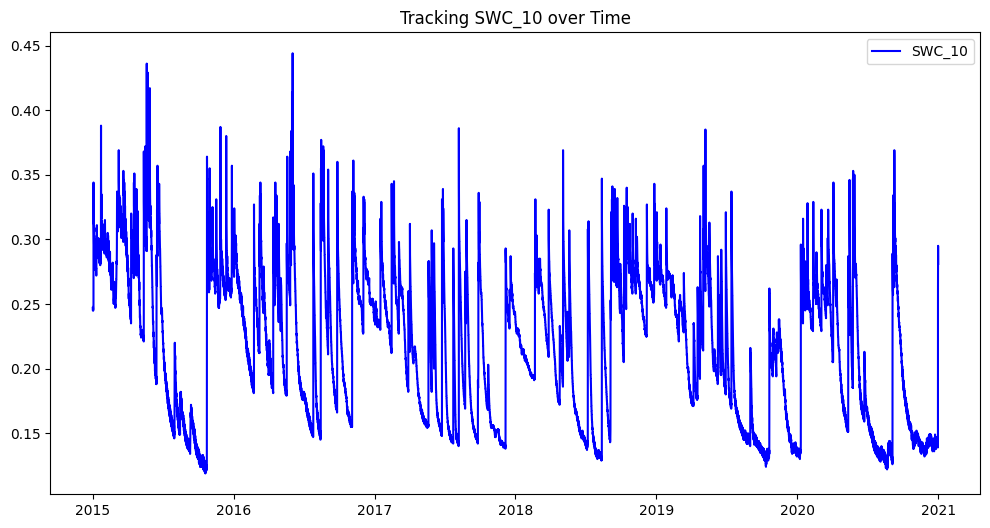

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(data.index, data[TARGET_COL], label=TARGET_COL,color="blue")
plt.title("Tracking " + TARGET_COL + " over Time")
plt.legend ()
plt.show()

A heatmap allow sus to see how well features correlate with each other, which reflects usefulness for including the features in a model.

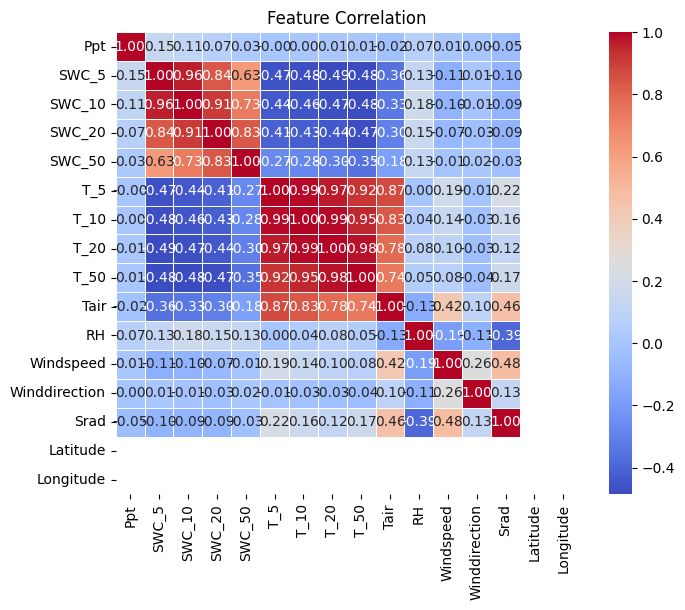

In [ ]:
# Check Correlations
numeric_data = data.select_dtypes(include=["float64"])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_data.corr(), annot=True, fmt=".2f", square=True,
    linewidths=0.5, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

Listing out the specific corr. values for our target feature

In [ ]:
swc_corr = numeric_data.corr()[TARGET_COL].sort_values(ascending=False)
print(swc_corr)

SWC_10           1.000000
SWC_5            0.962041
SWC_20           0.912022
SWC_50           0.728119
RH               0.180066
Ppt              0.110129
Winddirection   -0.013796
Srad            -0.091396
Windspeed       -0.095419
Tair            -0.332187
T_5             -0.441599
T_10            -0.455017
T_20            -0.468834
T_50            -0.480451
Latitude              NaN
Longitude             NaN
Name: SWC_10, dtype: float64


Fast Fourier Transform searches for seasonality in data, which helps us better find window/batch sizes and determine hyperparameters for seasonal models like SARIMA.

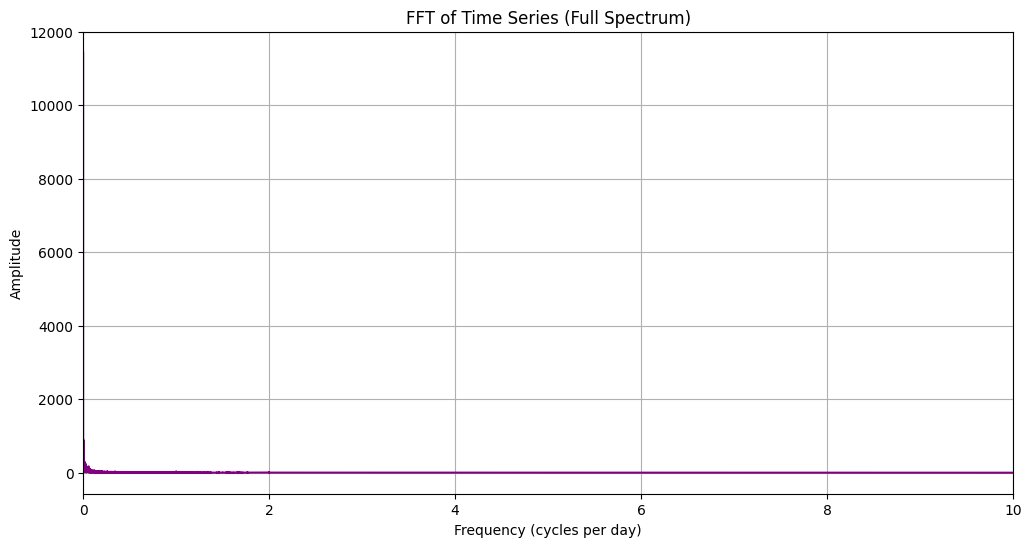

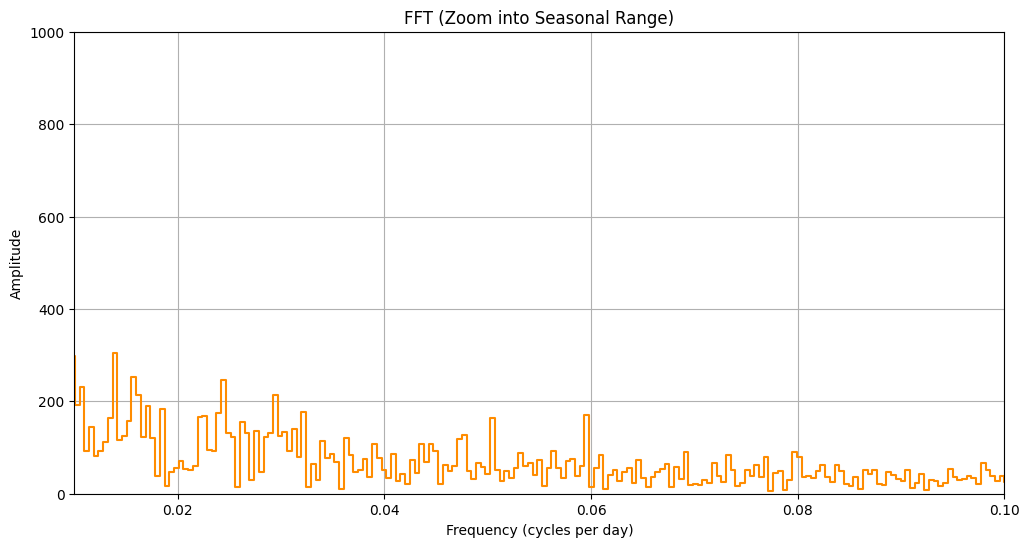

In [ ]:
plot_fft_analysis(data[TARGET_COL])